<a href="https://colab.research.google.com/github/varshamqa/AutomateBrowserSerVSC-M1/blob/master/AI_ML_Day3_Varsha_RestaurantRev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
data= pd.read_csv('/content/Restaurant_revenue (1).csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number_of_Customers        1000 non-null   int64  
 1   Menu_Price                 1000 non-null   float64
 2   Marketing_Spend            1000 non-null   float64
 3   Cuisine_Type               1000 non-null   object 
 4   Average_Customer_Spending  1000 non-null   float64
 5   Promotions                 1000 non-null   int64  
 6   Reviews                    1000 non-null   int64  
 7   Monthly_Revenue            1000 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 62.6+ KB


In [ ]:
data.shape

(1000, 8)

In [ ]:
data.tail(10)

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
990,43,34.779910,10.967641,Japanese,17.314581,0,51,323.610360
991,85,21.894202,17.585102,Japanese,19.296162,0,30,296.138161
992,44,27.213487,13.511602,American,35.425280,0,32,341.419451
993,10,16.826590,10.939265,Mexican,49.717739,0,12,139.180237
994,49,12.985193,16.595262,Italian,41.108700,1,17,229.953120
995,73,41.307842,12.122931,Japanese,19.033585,1,40,249.312034
996,31,20.615496,5.822885,Mexican,17.040990,0,57,110.228767
997,69,17.110656,4.141898,Japanese,44.649315,0,55,312.212552
998,73,37.664722,3.046556,Japanese,27.767358,0,23,272.482204
999,81,34.722067,17.989104,Italian,15.482112,1,72,379.973072


In [ ]:
data.dtypes

,0
Number_of_Customers,int64
Menu_Price,float64
Marketing_Spend,float64
Cuisine_Type,object
Average_Customer_Spending,float64
Promotions,int64
Reviews,int64
Monthly_Revenue,float64


In [ ]:
data.describe()

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.271000,30.219120,9.958726,29.477085,0.497000,49.837000,268.724172
std,26.364914,11.278760,5.845586,11.471686,0.500241,29.226334,103.982950
min,10.000000,10.009501,0.003768,10.037177,0.000000,0.000000,-28.977809
25%,30.000000,20.396828,4.690724,19.603041,0.000000,24.000000,197.103642
50%,54.000000,30.860614,10.092047,29.251365,0.000000,50.000000,270.213964
75%,74.000000,39.843868,14.992436,39.553220,1.000000,76.000000,343.395793
max,99.000000,49.974140,19.994276,49.900725,1.000000,99.000000,563.381332


In [ ]:
data.isnull().sum()

,0
Number_of_Customers,0
Menu_Price,0
Marketing_Spend,0
Cuisine_Type,0
Average_Customer_Spending,0
Promotions,0
Reviews,0
Monthly_Revenue,0


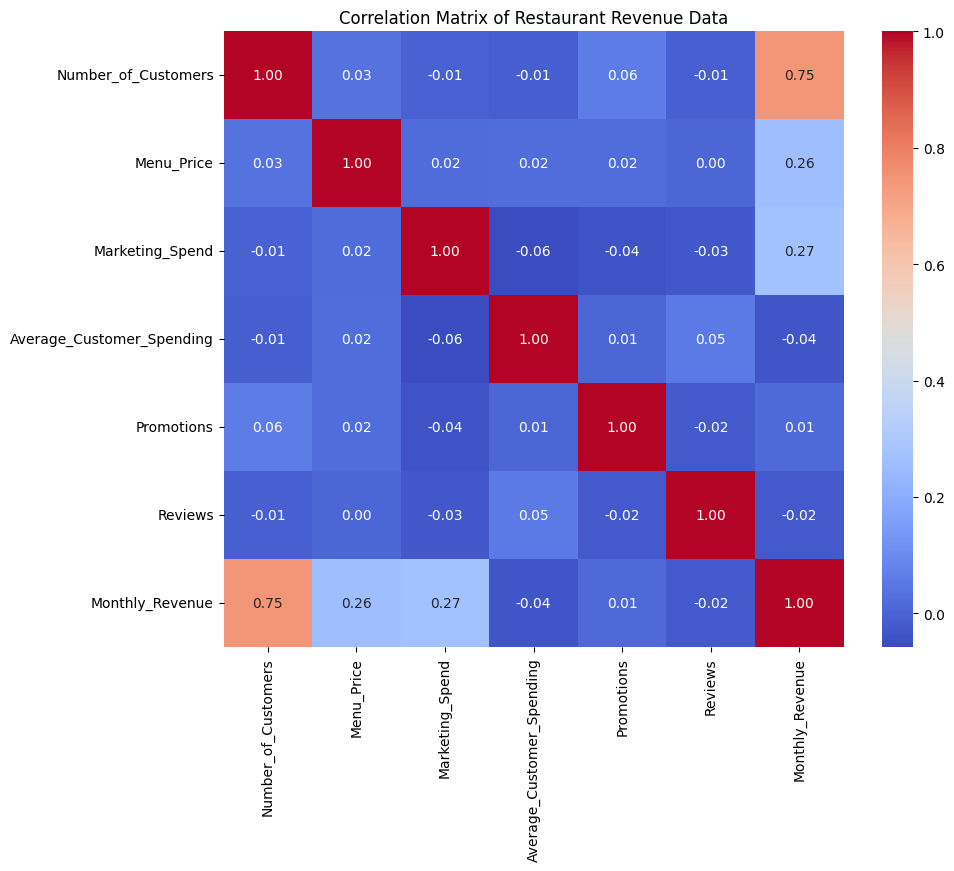

In [ ]:
correlation_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Restaurant Revenue Data')
plt.show()

### Scatter Plot: Monthly_Revenue vs Number_of_Customers

This plot visualizes the relationship between the number of customers and monthly revenue. We expect to see a positive trend based on the correlation matrix.

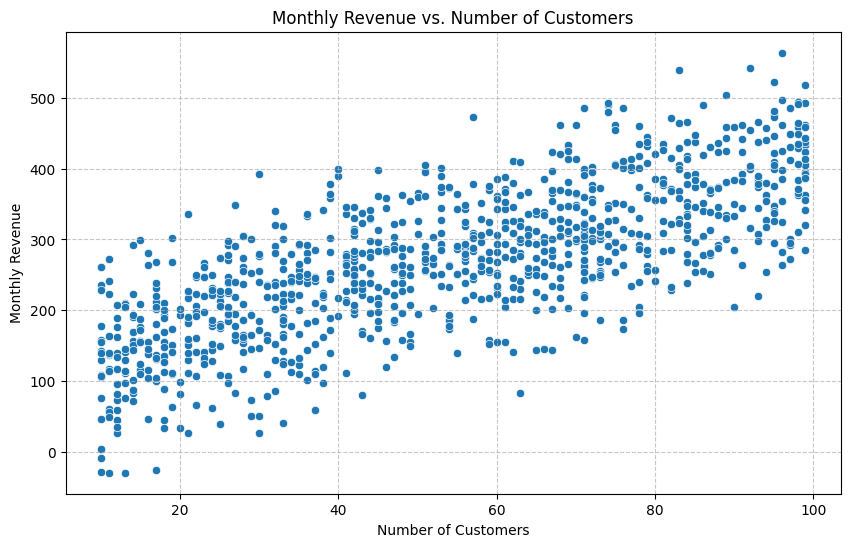

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Number_of_Customers', y='Monthly_Revenue', data=data)
plt.title('Monthly Revenue vs. Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Monthly Revenue')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print(f"Number of duplicate values :- {data.duplicated().sum()}")

Number of duplicate values :- 0


In [ ]:
data.Cuisine_Type.unique()

array(['Japanese', 'Italian', 'American', 'Mexican'], dtype=object)

In [ ]:
data.Cuisine_Type.value_counts()

,count
Cuisine_Type,
Japanese,262
American,256
Mexican,250
Italian,232


In [ ]:
data.rename(columns={'Number_of_Customers':'no_customerrs','Average_Customer_Spending':'avg_spending'}, inplace=True)
data.columns= data.columns.str.lower()

In [ ]:
data.columns

Index(['no_customerrs', 'menu_price', 'marketing_spend', 'cuisine_type',
       'avg_spending', 'promotions', 'reviews', 'monthly_revenue'],
      dtype='object')

In [ ]:
import plotly.express as px
px.line(x=data.index,y=data.monthly_revenue,title='Monthly Revenue Trend ' ).show()

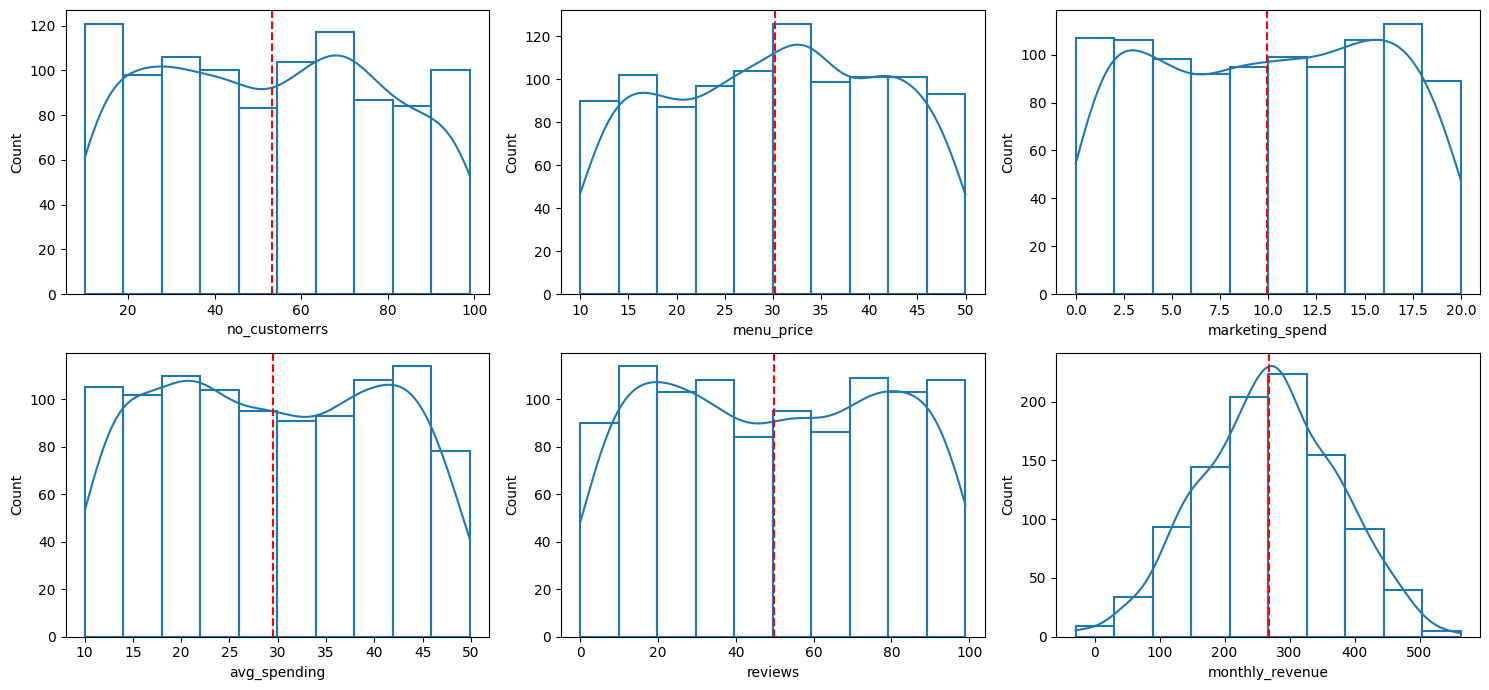

In [ ]:
fig,ax=plt.subplots(2,3,figsize=(15,7))
ax=ax.flatten()

for i,cols in enumerate(data.select_dtypes('number').drop(columns=['promotions']).columns):
    sns.histplot(kde=True,bins=10,x=data[cols],fill=False,ax=ax[i])
    ax[i].axvline(data[cols].mean(),color='red',linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
for i in data.select_dtypes('number').drop(columns=['promotions']).columns:
    print(f"{i} : {data[i].skew()}")

no_customerrs : 0.04493802939824041
menu_price : -0.05532986460496195
marketing_spend : -0.026283414130856227
avg_spending : 0.025267804042868925
reviews : 0.01822262216889947
monthly_revenue : -0.05572841669570578


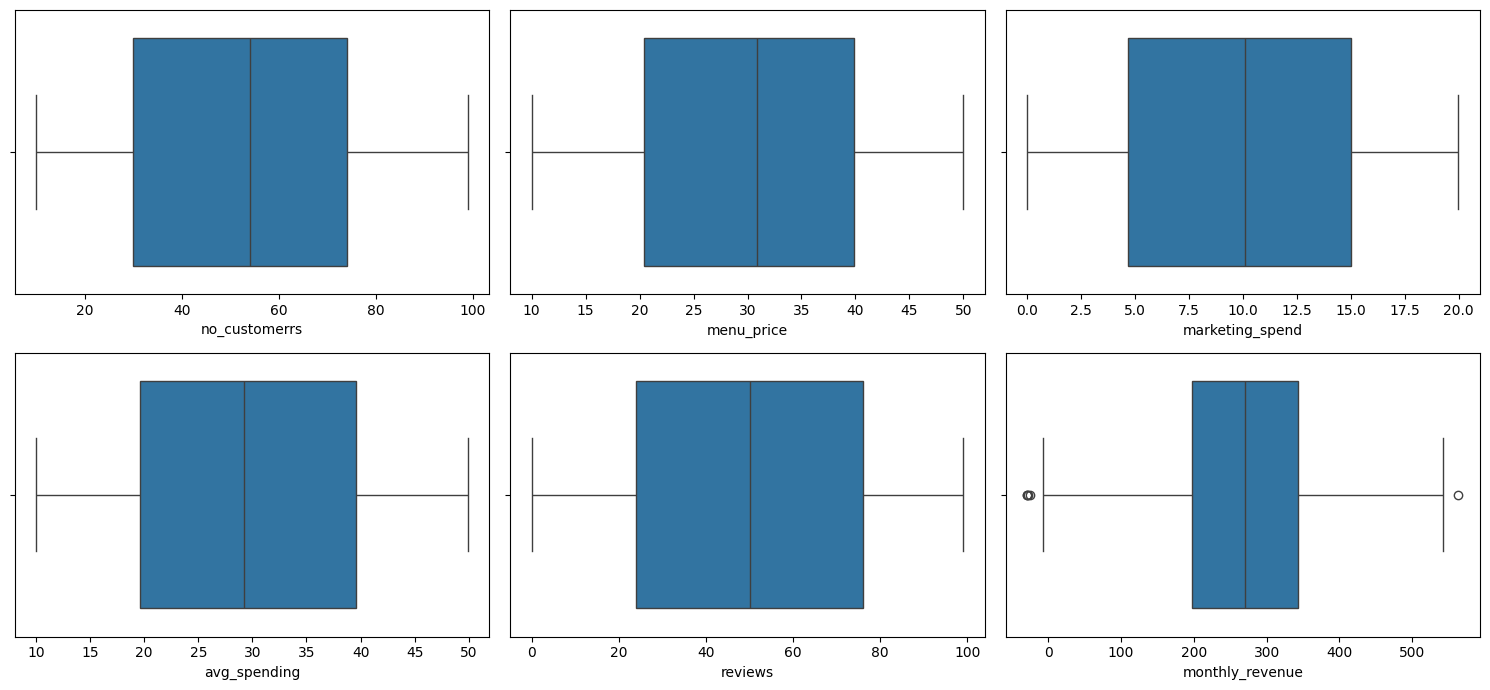

In [ ]:
fig,ax=plt.subplots(2,3,figsize=(15,7))
ax=ax.flatten()

for i,cols in enumerate(data.select_dtypes('number').drop(columns=['promotions']).columns):
    sns.boxplot(x=data[cols],ax=ax[i])
plt.tight_layout()
plt.show()

In [ ]:
px.bar(data_frame=data,x='cuisine_type',y='avg_spending').show()

In [ ]:
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , r2_score
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer , TransformedTargetRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler,OrdinalEncoder

In [ ]:
X=data.iloc[:,:-1]
y=data['monthly_revenue']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=43)

In [ ]:
X_train

,no_customerrs,menu_price,marketing_spend,cuisine_type,avg_spending,promotions,reviews
147,72,42.029991,6.847673,American,36.774279,0,93
88,89,22.457771,10.293152,American,10.984719,0,6
731,26,34.024382,16.335139,Italian,36.143471,1,48
741,74,49.733477,17.051156,Italian,24.774165,0,33
36,71,41.142878,2.984756,American,20.144511,1,47
...,...,...,...,...,...,...,...
277,33,35.557975,19.496693,American,31.398667,1,14
817,30,46.710100,2.088083,Mexican,47.433045,1,65
255,40,28.969492,8.703608,American,22.308113,1,54
320,73,26.700243,15.834000,Mexican,23.051286,0,13


In [ ]:
cols=ColumnTransformer(
    [
        ('encode',OrdinalEncoder(),['cuisine_type']),
        ('std',StandardScaler(),['no_customers','menu_price','marketing_spend','avg_spending','reviews'])
    ],
    remainder='passthrough'
)

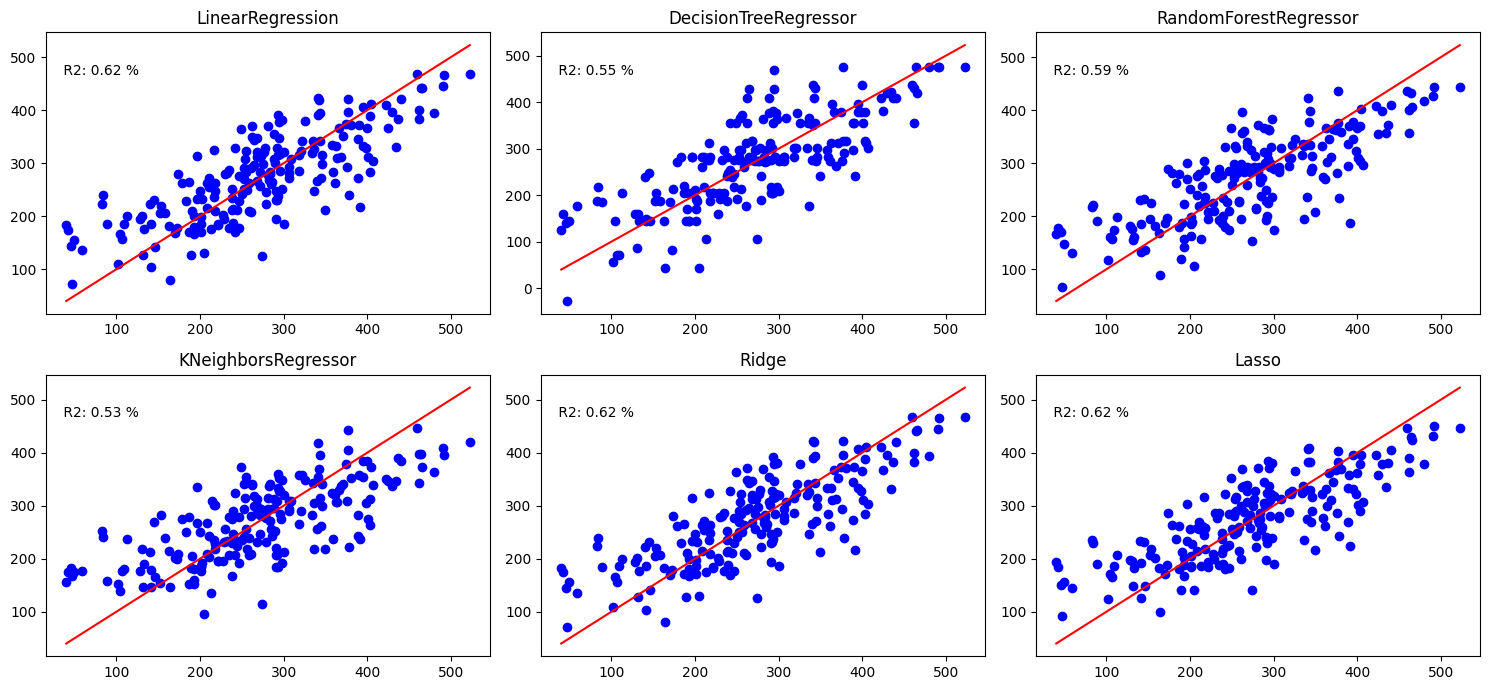

In [ ]:
models=[LinearRegression(),DecisionTreeRegressor(max_depth=7),
        RandomForestRegressor(max_depth=5,n_estimators=150,random_state=43),KNeighborsRegressor(n_neighbors=6,metric='euclidean')
       , Ridge(), Lasso(max_iter=200,alpha=0.05)]

fig,ax=plt.subplots(2,3,figsize=(15,7))
ax=ax.flatten()

# Correcting the ColumnTransformer to use the right column name 'no_customerrs'
cols=ColumnTransformer(
    [
        ('encode',OrdinalEncoder(),['cuisine_type']),
        ('std',StandardScaler(),['no_customerrs','menu_price','marketing_spend','avg_spending','reviews'])
    ],
    remainder='passthrough'
)

# subplot for comparing model performance
for i , model in enumerate(models):
    pipeline=Pipeline([
        ('cols',cols),
        ('model',TransformedTargetRegressor(
    regressor=model,
    transformer=StandardScaler()
                                            )
        )
                    ]
                     )

    pipeline.fit(X_train,y_train)

    y_pred=pipeline.predict(X_test)    #Predicting the model performance

    ax[i].plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],label='Actual',color='red')
    ax[i].scatter(y_test,y_pred,label='Predicted Values',color='blue')
    ax[i].text(s=f" R2: {r2_score(y_test,y_pred):.2f} %",x=0.03,y=0.85,transform=ax[i].transAxes)
    ax[i].set_title(model.__class__.__name__)
plt.tight_layout()
plt.show()

In [ ]:
models = {
    'LinearRegression' : LinearRegression(),
    'Ridge' : Ridge(),
    'rf': RandomForestRegressor(random_state=42)
}

# Parameter grids for each model
param_grids = {
    'LinearRegression' : {'fit_intercept': [True, False],'n_jobs': [None, -1]},
    'Ridge': {'alpha': [0.1, 1.0, 10.0]},
    'rf': {'n_estimators': [100, 200], 'max_depth': [None, 5, 10]}
}

In [ ]:
numeric_features = ['no_customerrs', 'menu_price', 'marketing_spend', 'avg_spending', 'reviews']
categorical_features = ['cuisine_type', 'promotions']

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_features])
X_test_num = scaler.transform(X_test[numeric_features])

encoder = OrdinalEncoder()
X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

X_train_transformed = np.hstack([X_train_num, X_train_cat])
X_test_transformed = np.hstack([X_test_num, X_test_cat])

In [ ]:
best_estimators = {}

for name in models:
    print(f"Running GridSearchCV for {name}...")

    grid = GridSearchCV(
        estimator=models[name],
        param_grid=param_grids[name],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid.fit(X_train_transformed, y_train)  # X_train_processed, y_train already preprocessed
    best_estimators[name] = grid.best_estimator_

    print(f"Best params for {name}: {grid.best_params_}")
    print(f"Best CV score for {name}: {grid.best_score_}\n")

Running GridSearchCV for LinearRegression...
Best params for LinearRegression: {'fit_intercept': True, 'n_jobs': None}
Best CV score for LinearRegression: 0.6848660465968779

Running GridSearchCV for Ridge...
Best params for Ridge: {'alpha': 10.0}
Best CV score for Ridge: 0.6851226885422507

Running GridSearchCV for rf...
Best params for rf: {'max_depth': 5, 'n_estimators': 200}
Best CV score for rf: 0.6449263029679061



In [ ]:
y_pred

array([370.9357457 , 273.86806721, 237.57029116, 239.52511994,
       395.24893844, 383.30230622, 262.31363179, 147.72061661,
       193.8180408 , 382.91293001, 312.35114235, 315.48673316,
       405.5872189 , 207.26613629, 361.17817971, 382.17993433,
       183.2294257 , 218.58579539, 225.48966856, 344.40320788,
       358.40690194, 140.53762896, 230.38113776, 205.52577985,
       180.33186581, 286.38195368, 315.79938835, 335.7426142 ,
       187.91497745, 298.93884276, 211.3336549 , 277.87568304,
       316.1768055 , 186.3439805 , 262.57915521, 380.34676738,
       190.99399576, 403.83541176, 312.36199785, 194.54240712,
       285.8713082 , 212.05204213, 304.05214178, 274.24589293,
       214.63504597, 149.80346945, 384.14111274, 257.79013984,
       185.25433004, 261.36388026, 331.25477801, 276.40811759,
       266.6275251 , 285.60104325, 396.26438106, 125.19354295,
       240.80417096, 432.16547503, 183.09156966, 218.50731972,
       233.29739831, 186.92867012, 336.8831391 , 301.15